In [37]:
import pandas as pd
import numpy as np
import zipfile
from matplotlib import pyplot as py
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import time
from sklearn.metrics import accuracy_score,roc_auc_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
import joblib

### 1 - Dataset loading from local

In [3]:
#Personal lap path
zip_path = r"D:\Veena\Certificate Program in AI and ML\Dataset.zip"
#office lap path
#zip_path = r"E:\Veena\Certificate-Program-in-AIML-IIT-Patna\MODULE 2 - CLASSICAL ML\Dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    ibmTelecoChurnDF = pd.read_csv(z.open("Dataset/telco_customer_churn.csv"))


In [4]:
ibmTelecoChurnDF.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2 - Checking if any null values are present in the dataset

In [5]:
ibmTelecoChurnDF.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
ibmTelecoChurnDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3 - Checking the distribution of values in the target column

In [7]:
ibmTelecoChurnDF['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
ibmTelecoChurnDF['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### 4 - Plotting the target column

<Axes: xlabel='Churn', ylabel='count'>

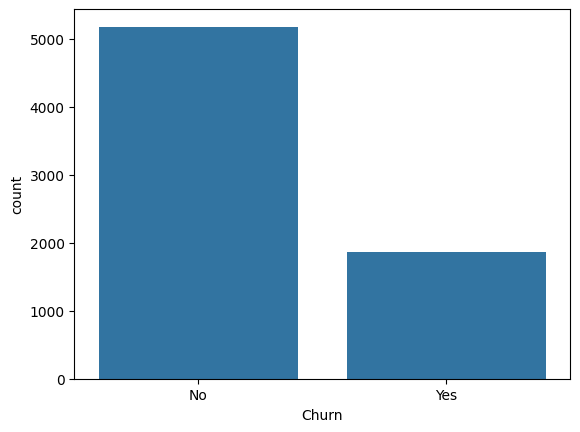

In [9]:
churnCount = ibmTelecoChurnDF['Churn'].value_counts()
sns.barplot(churnCount)

([<matplotlib.patches.Wedge at 0x2730c45d940>,
 [Text(-0.7393678155529122, 0.8144539479458092, 'No'),
  Text(0.7393680809356542, -0.8144537070291521, 'Yes')])

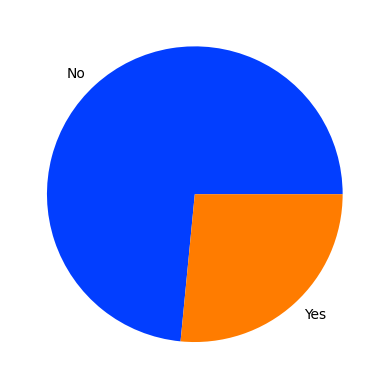

In [10]:
colours = sns.color_palette('bright')
py.pie(churnCount.values, labels=churnCount.index,colors=colours)

#### From above, it is clear that the dataset is imbalanced.

- And also, the "Total Charges" column is in string format.

In [11]:
sum(ibmTelecoChurnDF['TotalCharges'] == ' ')

11

In [12]:
ibmTelecoChurnDF['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [13]:
ibmTelecoChurnDF.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

### 5. Converting "Churn" column to binary values

In [14]:
#Converting the obtained boolean value(Yes-> 1, No-> 0) from ibmTelecoChurnDF['Churn'] == 'Yes', to integer type as 1 and 0.
ibmTelecoChurnDF['ChurnInt'] = (ibmTelecoChurnDF['Churn'] == 'Yes').astype(int)
ibmTelecoChurnDF['ChurnInt'].value_counts()

ChurnInt
0    5174
1    1869
Name: count, dtype: int64

In [15]:
ibmTelecoChurnDF.groupby('Contract')['ChurnInt'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnInt, dtype: float64

In [16]:
ibmTelecoChurnDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 6 - Fixing the issues in the dataset

#### 6.1 - Converting "Total Charges" column to float type and replacing the null values with median of the column

In [17]:
#Convert "Total Charges" column into numeric
ibmTelecoChurnDF['TotalCharges'] = pd.to_numeric(ibmTelecoChurnDF['TotalCharges'],errors='coerce')


In [18]:
ibmTelecoChurnDF['TotalCharges']=ibmTelecoChurnDF['TotalCharges'].fillna(0)
ibmTelecoChurnDF['TotalCharges'].info()

<class 'pandas.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


#### 6.2 - Dropping the "customerID" column as it is not required for model building

In [19]:

#Droping the unnecessary column - customer ID
ibmTelecoChurnDF = ibmTelecoChurnDF.drop('customerID',axis=1)

In [20]:
ibmTelecoChurnDF.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'ChurnInt'],
      dtype='str')

#### 6.3 - Seperating the categorical and numerical columns and defining a preprocessor to handle for the categorical and numerical columns

In [21]:
numCols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
#+ mean, do not include the columns present in numCols and also Churn and ChurnInt
catogoryCols = [c for c in ibmTelecoChurnDF.columns if c not in numCols + ['Churn','ChurnInt']]

print(f"Numeric columns: {numCols}")
print(f"Category columns: {catogoryCols}")

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Category columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [22]:
## Building a Prepocessor
## Usually, we use to apply standard scalar on numeric columns and on-hot encoding omn categorical columns. This is a away of doing manually. But this can be automated.
#The below is just definition of the automated column transformer.
#This is like telling python, the steps to perform.
preprocessor = ColumnTransformer(
    [
        ('num',StandardScaler(),numCols),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),catogoryCols)
    ]
)

### 7 - Splitting the dataset into train and test sets

In [23]:
x = ibmTelecoChurnDF.drop(['Churn','ChurnInt'],axis=1)
y = ibmTelecoChurnDF['ChurnInt']

xTrain,xTest,yTrain,yTest = train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)

print(f"Train samples : {len(xTrain)} samples | Churn Rate: {yTrain.mean():.2%}")
print(f"Test samples : {len(xTest)} samples | Churn Rate: {yTest.mean():.2%}")

Train samples : 5282 samples | Churn Rate: 26.54%
Test samples : 1761 samples | Churn Rate: 26.52%


In [24]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [25]:
ibmTelecoChurnDF.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnInt
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


### 8 - Models declaration

In [26]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=42),
    #Below,n_jobs means how many cpu cores to use to run computation in paralle. -1 indicates use all cores available in my lap.
    'Random Forest' : RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)
}

### 9 - Model training,prediction and evaluation

In [27]:
results=[]
trainedPipelines ={}

for name,model in models.items():
    mlPipeLine = Pipeline([('Preprocessing',preprocessor),
                           ('model',model)])
    t0=time.time()
    mlPipeLine.fit(xTrain,yTrain)
    elapsed = time.time() - t0

    yPred = mlPipeLine.predict(xTest)
    yProba = mlPipeLine.predict_proba(xTest)[:,1]
    crossValScore = cross_val_score(mlPipeLine,xTrain,yTrain,cv=5,scoring='roc_auc')

    results.append({
        'Model':name,
        'Accuracy': accuracy_score(yTest,yPred),
        'Precision':precision_score(yTest,yPred),
        'Recall':recall_score(yTest,yPred),
        'F1':f1_score(yTest,yPred),
        'ROC AUC Score':roc_auc_score(yTest,yPred),
        'mean of CrossValScore':crossValScore.mean(),
        'std of CrossValScore':crossValScore.std(),
        'Training Time':round(elapsed,3)
        })
    trainedPipelines[name] = mlPipeLine
comparisionDF = pd.DataFrame(results)
print("*" * 80)
print("BASELINE COMPARISION TABLE")
print("*" * 80)
print(comparisionDF.round(4).to_string(index=False))



********************************************************************************
BASELINE COMPARISION TABLE
********************************************************************************
              Model  Accuracy  Precision  Recall     F1  ROC AUC Score  mean of CrossValScore  std of CrossValScore  Training Time
Logistic Regression    0.7501     0.5188  0.7966 0.6284         0.7650                 0.8437                0.0126          0.183
      Decision Tree    0.7376     0.5035  0.7602 0.6058         0.7448                 0.8243                0.0106          0.130
      Random Forest    0.7831     0.6218  0.4647 0.5319         0.6813                 0.8208                0.0135          0.862


## 10 - Hyper parameter tuning using GridSearchCV
- Usually, in RandomForest we have many parameters like n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features etc. We cannot create multiple models, with different combo values of the parameters and check which one is the best. 
- So, we use GridSearchCV to find the best parameters for the model. This is done by creating a dictionary of parameters and their values, and then passing it to the GridSearchCV along with the model. It will create multiple models with different combo values of the parameters and check which one is the best. It will return the best parameters and the best score.
- Internally, we use cross validation to find the best parameters. It will split the training data into k folds and train the model on k-1 folds and test on the remaining fold. It will do this for all the folds and return the average score. This is done to avoid overfitting.
- In this case, we will perform Hynperparameter tuning for Rnadom Forest with 5 fold cross validation. So, the training data will be split into 5 folds and the model will be trained on 4 folds and tested on the remaining fold. This will be done for all the folds and the average score will be returned.

In [28]:
rfPipeLine = Pipeline([(
    'preprocessor',preprocessor),
    ('MLmodel',RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1)) #We didn't give the above mentioned parameters here because we will tyne the hyperparameters and find the best one.
])
paramsList={
    #The prefix of parameter should be name given to model in pipeline(MLmodel)
    "MLmodel__n_estimators":[20,30,50,150,500],
    "MLmodel__max_depth":[3,4,5,6,7],
    "MLmodel__min_samples_split":[3,5,10,12,15]
}
#n_splits meand no.of test train sets to make, for training the model.
crossVal = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [29]:
#Here there will be 15(total no.of values in all params) * 3(total no.of params) * 5(no.of splits for cross val) = 225 models are trained.
gridsearchCrossVal = GridSearchCV(
    rfPipeLine,
    paramsList,
    cv=crossVal,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
print("Running Gris search (45 combinations * 5 folds = 225 models)")
gridsearchCrossVal.fit(xTrain,yTrain)

Running Gris search (45 combinations * 5 folds = 225 models)
Fitting 5 folds for each of 125 candidates, totalling 625 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'MLmodel__max_depth': [3, 4, ...], 'MLmodel__min_samples_split': [3, 5, ...], 'MLmodel__n_estimators': [20, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [30]:
print(f"Best hyper parameters using GrisSearchCV:: {gridsearchCrossVal.best_params_}")

Best hyper parameters using GrisSearchCV:: {'MLmodel__max_depth': 7, 'MLmodel__min_samples_split': 15, 'MLmodel__n_estimators': 50}


In [31]:
print(f"Best score obtained for best hyper parameters using GrisSearchCV:: {gridsearchCrossVal.best_score_:.4f}")

Best score obtained for best hyper parameters using GrisSearchCV:: 0.8460


### 11 - Hyper parameter tuning using RandomSeachCV
- RandomSearchCV is similar to GridSearchCV, but instead of trying all the combinations of parameters, it will try a random combination of parameters. This is useful when we have a large number of parameters and we want to find the best combination of parameters in a reasonable time. It will return the best parameters and the best score.

In [32]:
randomsearchCrossVal = RandomizedSearchCV(
    rfPipeLine,
    paramsList,
    cv=crossVal,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
print("Running Random search (Random cobos of parameters)")
randomsearchCrossVal.fit(xTrain,yTrain)

Running Random search (Random cobos of parameters)
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'MLmodel__max_depth': [3, 4, ...], 'MLmodel__min_samples_split': [3, 5, ...], 'MLmodel__n_estimators': [20, 30, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

In [33]:
print(f"Best hyper parameters using RandomSearchCV:: {randomsearchCrossVal.best_params_}")

Best hyper parameters using RandomSearchCV:: {'MLmodel__n_estimators': 150, 'MLmodel__min_samples_split': 15, 'MLmodel__max_depth': 7}


In [34]:
print(f"Best score obtained for best hyper parameters using RandomSearchCV:: {randomsearchCrossVal.best_score_:.4f}")

Best score obtained for best hyper parameters using RandomSearchCV:: 0.8455


### 12 - Training the model with best parameters and evaluating the model on test data

In [35]:
bestModel = gridsearchCrossVal.best_estimator_
bestModel

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('MLmodel', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [41]:
yPred = bestModel.predict(xTest)
yProba = bestModel.predict_proba(xTest)[:,1]

print(f"Final Model:Random Forest");
print(f"Accuracy: {accuracy_score(yTest,yPred): .2%}")
print(f"Precision: {precision_score(yTest,yPred): .2%}")
print(f"Recall: {recall_score(yTest,yPred): .2%}")
print(f"F1 score : {f1_score(yTest,yPred): .2%}")
print(f"ROC AUC Score: {roc_auc_score(yTest,yPred): .2%}")
print(f"mean of CrossValScore: {crossValScore.mean(): .4f}")
print(f"std of CrossValScore: {crossValScore.std(): .4f}")

Final Model:Random Forest
Accuracy:  76.09%
Precision:  53.30%
Recall:  79.44%
F1 score :  63.80%
ROC AUC Score:  77.16%
mean of CrossValScore:  0.8208
std of CrossValScore:  0.0135


### 12 - Model saving 

In [40]:
joblib.dump(bestModel,"IBMTelecoCustomerChurnModel.pkl")

['IBMTelecoCustomerChurnModel.pkl']

### Final - Model loading
- This will be in a new file called "TelecoChurnPrediction_Model_Saving_Loading.ipynb" as this is not part of the model building process. This will be done in a new file to avoid confusion and to keep the model building process clean and simple, and also to understand how prediction will be done in a new file by loading the model alone.